# Optimal scaling in the corrupted-signal problem

**What "optimal" means here.** Every candidate is a draw of a noise coefficient $c \sim U[0,1]$ on
a random target index. The only way to hold cleaner features is to draw more candidates and keep
the best, so the best any method can do is fixed by two facts: how good the best of $m$ draws is,
and how many draws a step can buy.

**1. Best of $m$ draws.** For one target index, the smallest coefficient among $m$ draws has
$\mathbb{E}[c^2] = 2/((m+1)(m+2)) \approx 2/m^2$.

**2. What a coefficient costs.** A feature with coefficient $c$ leaves
$\tfrac13\, c^2 / ((1-c)^2 + c^2) \approx c^2/3$ of its index's variance unexplained. Summed over
the $n$ indices, the loss above the noise floor is

$$\text{excess} \;\approx\; \sum_i \frac{c_i^2}{3} \;\approx\; \frac{2n}{3m^2}.$$

Loss is quadratic in $c$: halving the best coefficient quarters the excess.

**3. How many draws a step buys.** With $n$ spare slots you can draw at most one candidate per
slot per step, so after $t$ steps $m \le t$, and

$$\boxed{\;\text{excess}(t) \;\ge\; \frac{2n}{3t^2}\;}$$

This is the ceiling: excess loss falls as $t^{-2}$ and nothing beats it. It is an *oracle* rate — it
assumes a candidate's quality is known the instant it is drawn.

**Where a real method lands.** A real method needs $T$ steps to judge a candidate and tests $s$
slots at once, so $m = st/(nT)$ and

$$\text{excess}(t) \;\approx\; \frac{2n}{3t^2}\cdot\Big(\frac{nT}{s}\Big)^2 .$$

Same slope, shifted right by a factor $nT/s$ in time. Testing one slot at a time ($s=1$) versus all
$n$ ($s=n$) is therefore a factor of $n$ in time — $n^2$ in loss at any fixed $t$ — but **not a
change of exponent**.

**The one thing that does change the exponent is $T$ growing as features get cleaner.** If a
test takes $T \propto c^{-p}$ steps to resolve against an incumbent of quality $c$, draws slow down
as the incumbents improve:

| test time $T$ | draws $k(t)$ | excess loss |
|---|---|---|
| constant | $\propto t$ | $\propto t^{-2}$ |
| $\propto 1/c$ | $\propto t^{1/2}$ | $\propto t^{-1}$ |
| $\propto 1/c^2$ | $\propto t^{1/3}$ | $\propto t^{-2/3}$ |

(in general $T \propto c^{-p}$ gives $t^{-2/(p+1)}$). This is a live risk for gradient-based
tests: two near-clean copies of the same index are nearly collinear, and LMS resolves the direction
between them at a rate $\propto c^2$. The *information* to rank them in constant time is there —
with both in the model the fitted weights split as $c'^2 : c^2$, an $O(1)$ ratio however small $c$
is — but a test has to be built to extract it.

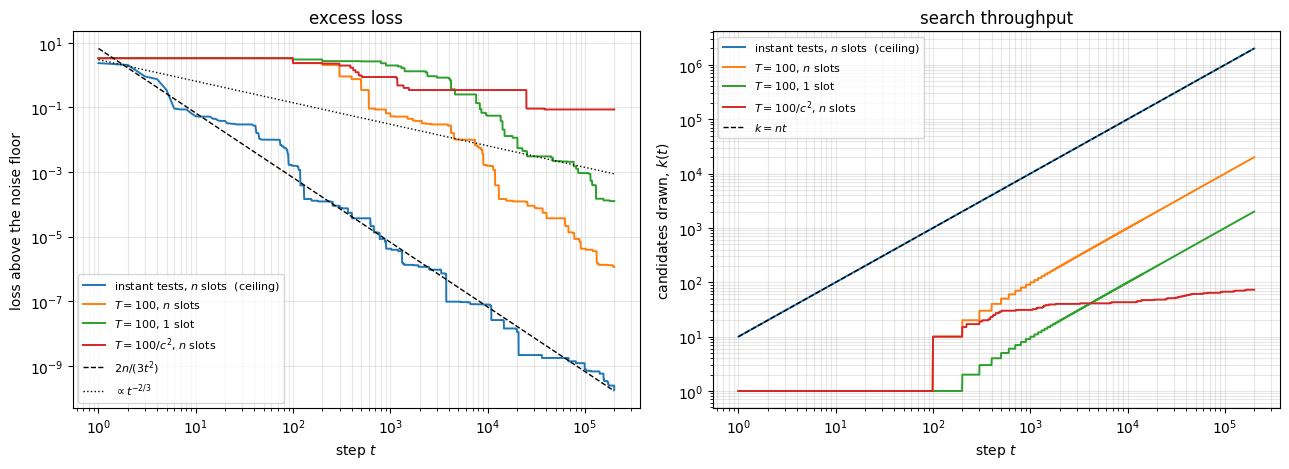

In [1]:
import numpy as np
import matplotlib.pyplot as plt

N, STEPS, T0 = 10, 200_000, 100

def excess(best):
    """Exact loss above the noise floor for the held coefficients (1 = index not covered)."""
    return np.sum(best ** 2 / ((1 - best) ** 2 + best ** 2)) / 3

def sift(n_slots, test_time, seed=0):
    """A perfect-decision sifter: each of `n_slots` spare slots holds one candidate for
    `test_time(c_incumbent)` steps, keeps it iff it beats the incumbent, then redraws.
    Decisions are always right, so only *throughput* separates the runs."""
    rng = np.random.default_rng(seed)
    best = np.ones(N)
    idx, c = rng.integers(0, N, n_slots), rng.uniform(0, 1, n_slots)
    timer = np.array([test_time(best[i]) for i in idx], float)
    draws, out_e, out_k = 0, np.empty(STEPS), np.empty(STEPS)
    for t in range(STEPS):
        timer -= 1
        for s in np.flatnonzero(timer <= 0):
            if c[s] < best[idx[s]]:
                best[idx[s]] = c[s]
            idx[s], c[s] = rng.integers(0, N), rng.uniform()
            timer[s] = test_time(best[idx[s]])
            draws += 1
        out_e[t], out_k[t] = excess(best), draws
    return out_e, out_k

runs = {
    'instant tests, $n$ slots  (ceiling)': sift(N, lambda c: 1),
    f'$T = {T0}$, $n$ slots':               sift(N, lambda c: T0),
    f'$T = {T0}$, 1 slot':                  sift(1, lambda c: T0),
    f'$T = {T0}/c^2$, $n$ slots':           sift(N, lambda c: T0 / c ** 2),
}

t = np.arange(1, STEPS + 1)
fig, (a, b) = plt.subplots(1, 2, figsize=(13, 4.8))
for label, (e, k) in runs.items():
    a.plot(t, e, lw=1.4, label=label)
    b.plot(t, np.maximum(k, 1), lw=1.4, label=label)
a.plot(t, 2 * N / (3 * t ** 2), 'k--', lw=1, label='$2n / (3t^2)$')
a.plot(t, 3 * t ** (-2 / 3), 'k:', lw=1, label='$\\propto t^{-2/3}$')
b.plot(t, N * t, 'k--', lw=1, label='$k = nt$')
for ax in (a, b):
    ax.set_xscale('log'); ax.set_yscale('log'); ax.set_xlabel('step $t$'); ax.grid(alpha=0.3, which='both')
a.set_ylabel('loss above the noise floor'); a.set_title('excess loss'); a.legend(fontsize=8)
b.set_ylabel('candidates drawn, $k(t)$'); b.set_title('search throughput'); b.legend(fontsize=8)
fig.tight_layout()
plt.show()

Left: the three constant-$T$ runs share the ceiling's slope and sit to its right by $T$ (all
$n$ slots) or $nT$ (one slot). The $T \propto 1/c^2$ run has a different slope altogether. Right:
the exponent on the left is entirely explained by the throughput on the right — excess is
$\propto 1/k^2$ in every case.

## Measuring it

Three curves, each log-log against $t$ with its ceiling drawn on:

1. **Throughput $k(t)$** — cumulative candidates drawn; every prune is one draw. Ceiling $k = nt$.
   Slope 1 means test time is constant; anything less means tests are slowing down and the exponent
   below will suffer. The distance below the ceiling is the average test time ($k = st/T$).
2. **Feature-set quality** — the loss floor of what is currently held,
   $\sum_i \tfrac13\, c_i^2 / ((1-c_i)^2 + c_i^2)$, read from the task's `noise_coefficients`.
   Ceiling $2n/(3t^2)$. Slope $-2$ with a constant horizontal offset means optimal up to that
   constant. If $k(t)$ is at its ceiling but this is not, the *decisions* are wrong — keeping bad
   draws or discarding good ones — which is what separates the test from the search. (The existing
   `noise_floor` diagnostic sums $c_i$ linearly; use the squared form so it compares against the
   ceiling directly.)
3. **Actual excess loss** — loss $- \sigma^2$. It sits above (2) by the learner's tracking error,
   so the gap between (3) and (2) is the learner's inefficiency, not the search's.

Near-optimal then reads off as: slope 1 on (1), slope $-2$ on (2) and (3), and a horizontal
offset from the ceiling that is a constant not growing with $n$. Fit slopes over the last decade
of $t$; a slope between $-1$ and $-2/3$ on (2) says the tests are slowing as the features improve.